In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import importlib.util
import inspect
import random
import subprocess
import sys
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from PIL import Image
from IPython.display import display

import torch
from transformers import AutoProcessor,AutoModelForZeroShotObjectDetection

In [3]:
PROJECT = Path("/content/drive/MyDrive/Vision/vision_unit_04")
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

DATA_PARENT = Path("/content/datasets")
DATA = DATA_PARENT / "coco128-seg"

MANIFEST_PATH = OUTPUTS / "evaluation_manifest.csv"
DEVICE = "cuda"

TARGET_CLASSES = {
    0: "person",
    2: "car",
    16: "dog",
    41: "cup",
    56: "chair",
}

print("Device:", torch.cuda.get_device_name(0))
print("Classes:", list(TARGET_CLASSES.values()))

Device: Tesla T4
Classes: ['person', 'car', 'dog', 'cup', 'chair']


**Dataset and calibration/test split**

In [4]:
DATA_PARENT.mkdir(parents=True, exist_ok=True)

if not (DATA / "images/train2017").exists():
    archive = DATA_PARENT / "coco128-seg.zip"
    
    urllib.request.urlretrieve(
        "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip",
        archive,
    )
     
    with zipfile.ZipFile(archive) as z:
        z.extractall(DATA_PARENT)

image_paths = sorted((DATA / "images/train2017").glob("*.jpg"))

In [5]:
annotations = {}

for path in image_paths:
    label_path = DATA / "labels/train2017" / f"{path.stem}.txt"
    items = []
    
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
        
            values = line.split()
            items.append({
                "class_id": int(values[0]),
                "polygon_norm" : np.asarray(
                    values[1:], dtype=np.float32
                ).reshape(-1, 2)
            })
    annotations[path.name] = items

In [6]:
present = {
    name: {item["class_id"] for item in items}
    for name, items in annotations.items()
}

target_ids = set(TARGET_CLASSES)

In [7]:
if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)

else:
    rng = random.Random(42)
    remaining = set(present)
    records = []
    
    rare_first = sorted(
        TARGET_CLASSES, 
        key=lambda cid: sum(cid in ids for ids in present.values())
    )
    
    for split in ["calibration", "test"]:
        chosen = []
        
        for cid in rare_first:
            need = max(
                0, 3 - sum(cid in present[name] for name in chosen)
            )
            
            pool = sorted(
                name for name in remaining if cid in present[name]
            )
            
            picks = rng.sample(pool, need)
            chosen.extend(picks)
            remaining.difference_update(picks)
        

        pool = sorted(
            name for name in remaining
            if not (target_ids & present[name])
        )
        
        picks = rng.sample(pool, 2)
        chosen.extend(picks)
        remaining.difference_update(picks)
        
        pool = sorted(
            name for name in remaining
            if target_ids & present[name]
        )
        picks = rng.sample(pool, 20 - len(chosen))
        chosen.extend(picks)
        remaining.difference_update(picks)
        
        for name in sorted(chosen):
            records.append({
                "image_name": name,
                "split": split,
                "selected_classes": "|".join(
                    TARGET_CLASSES[cid]
                    for cid in TARGET_CLASSES
                    if cid in present[name]
                ),
                "selected_instances": sum(
                    item["class_id"] in target_ids
                    for item in annotations[name]
                )
            })
    
    manifest = pd.DataFrame(records)
    manifest.to_csv(MANIFEST_PATH, index=False)

In [8]:
coverage = []

for split, group in manifest.groupby("split"):
    names = group["image_name"].tolist()

    row = {
        "split": split,
        "images": len(names),
    }
    
    row.update({
        label: sum(cid in present[name] for name in names)
        for cid, label in TARGET_CLASSES.items()
    })

    row["negative_images"] = sum(
        not (target_ids & present[name])
        for name in names
    )
    coverage.append(row)

display(pd.DataFrame(coverage))

,split,images,person,car,dog,cup,chair,negative_images
0,calibration,20,9,4,3,4,4,2
1,test,20,12,4,5,3,4,2


**Load Model**

In [9]:
MODEL_ID = "IDEA-Research/grounding-dino-tiny"

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

processor = AutoProcessor.from_pretrained(MODEL_ID)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [10]:
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    MODEL_ID,
    disable_custom_kernels=True
).float().to(DEVICE).eval()

postprocess = processor.post_process_grounded_object_detection
parameters = inspect.signature(postprocess).parameters

BOX_ARGUMENT = (
    "threshold"
    if "threshold" in parameters
    else "box_threshold"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  689MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

**Inference and box function**

In [17]:
@torch.inference_mode()
def ground(image, prompt, box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD):
    image = image.convert("RGB")
    prompt = prompt.strip().lower()
    
    if not prompt.endswith("."):
        prompt += "."
    
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(DEVICE)
    
    outputs = model(**inputs)
    
    raw = postprocess(
        outputs,
        input_ids=inputs.input_ids,
        text_threshold=text_threshold,
        target_sizes=[(image.height, image.width)],
        **{BOX_ARGUMENT: box_threshold}
    )[0]
    
    labels = raw.get("text_labels", raw.get("labels", []))
    return {
        "prompt" : prompt,
        "boxes" : raw["boxes"].detach().cpu().numpy().reshape(-1, 4),
        "scores": raw["scores"].detach().cpu().numpy(),
        "labels": list(labels)
    }

In [12]:
def draw_grounding(ax, image, result, title):
    ax.imshow(image)
    
    for i, (box, score, label) in enumerate(zip(
        result["boxes"],
        result["scores"],
        result["labels"],
    )):
        x1, y1, x2, y2 = box
        color = plt.get_cmap("tab10")(i % 10)
        
        ax.add_patch(Rectangle(
            (x1, y1),
            x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2
        ))
        ax.text(
            x1,
            max(0, y1 - 4),
            f"{label or '(empty phrase)'} {score:.2f}",
            fontsize=8,color="white",
            bbox={
                "facecolor": color,
                "alpha": 0.85,
                "pad": 2,
            },
        )
    
    ax.set_title(
        f"{title}: {len(result['boxes'])} boxes\n{result['prompt']}",
        fontsize=10,
    )

    ax.set_xlim(0, image.width)
    ax.set_ylim(image.height, 0)
    ax.axis("off")

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


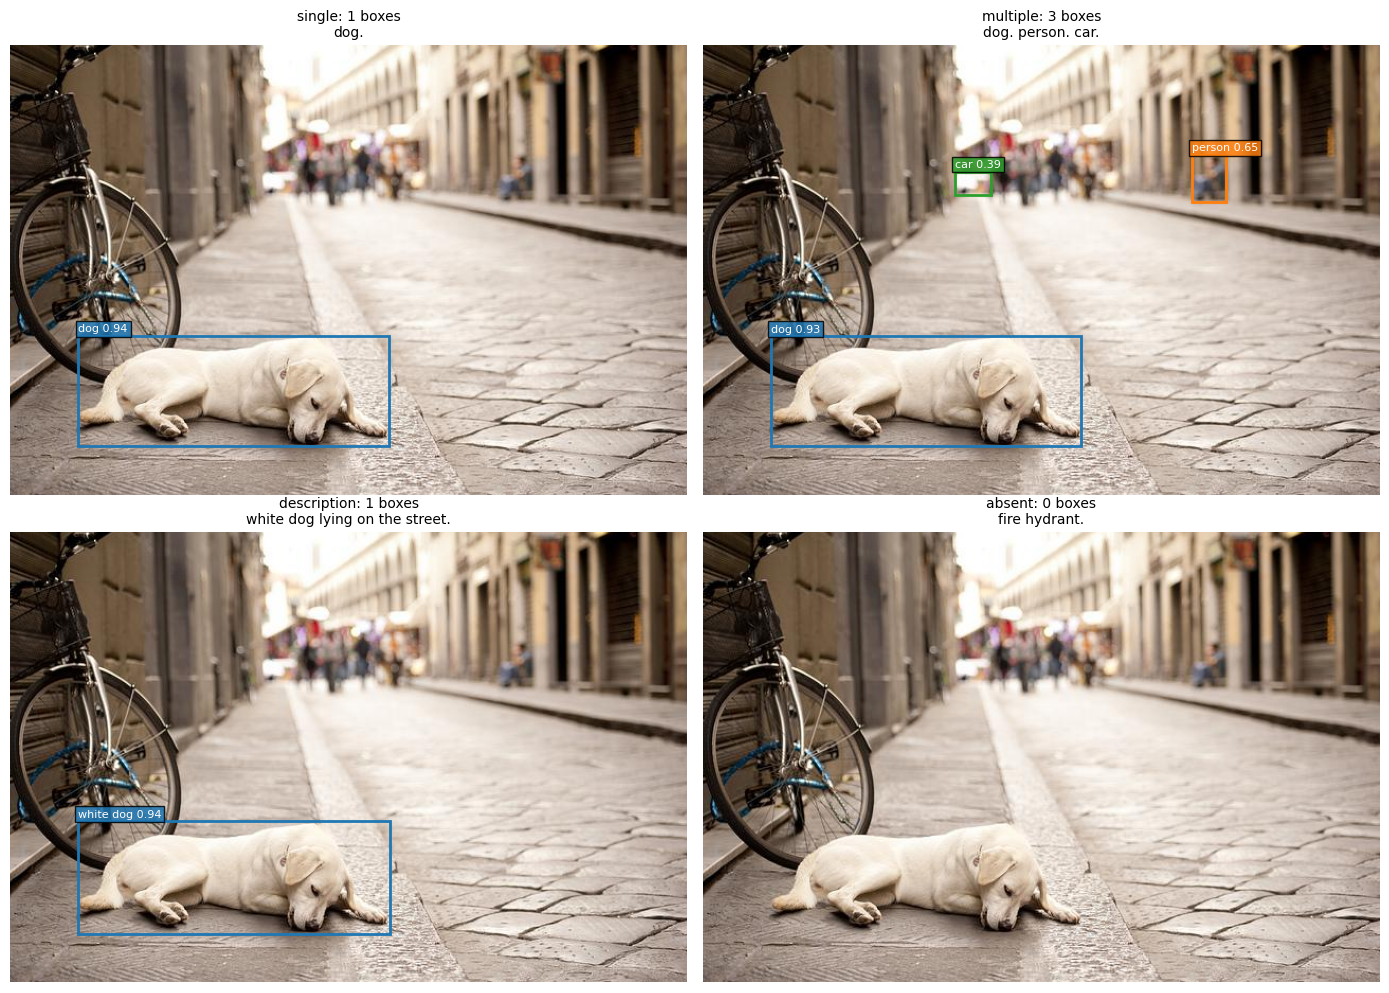

,case,prompt,box_count,labels,scores
0,single,dog.,1,dog,[0.938]
1,multiple,dog. person. car.,3,dog | person | car,"[0.929, 0.654, 0.388]"
2,description,white dog lying on the street.,1,white dog,[0.94]
3,absent,fire hydrant.,0,,[]


In [22]:
DEMO_NAME = "000000000074.jpg"
calibration_names = set(
    manifest.loc[manifest["split"] == "calibration", "image_name"]
)

image = Image.open(DATA / "images/train2017" / DEMO_NAME).convert("RGB")
cases = [
    ("single", "dog."),
    ("multiple", "dog. person. car."),
    ("description", "white dog lying on the street."),
    ("absent", "fire hydrant."),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

results = {}
rows = []

for ax, (case, prompt) in zip(axes.flat, cases):
    result = ground(image, prompt)
    results[case] = result
    draw_grounding(ax, image, result, case)

    rows.append({
        "case": case,
        "prompt": result["prompt"],
        "box_count": len(result["boxes"]),
        "labels": " | ".join(result["labels"]),
        "scores": [
            round(float(score), 3)
            for score in result["scores"]
        ],
    })

plt.tight_layout()
plt.show()

summary = pd.DataFrame(rows)
display(summary)

In [20]:
print("Single-prompt boxes [x1, y1, x2, y2]:")
print(np.round(results["single"]["boxes"], 1))

print(
    "Description tokens:",
    processor.tokenizer.tokenize(cases[2][1]),
)

Single-prompt boxes [x1, y1, x2, y2]:
[[ 64.7 274.9 357.9 378.8]]
Description tokens: ['white', 'dog', 'lying', 'on', 'the', 'street', '.']
